<a href="https://colab.research.google.com/github/AnuBolishetty/Anubolishetty_INFO5731_Spring2026/blob/main/Bolishetty_Anu_Assignment_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# **INFO5731 Assignment 2**

In this assignment, we will delve into various aspects of natural language processing (NLP) and text analysis. The tasks are designed to deepen your understanding of key NLP concepts and techniques, as well as to provide hands-on experience with practical applications.

Through these tasks, you'll gain practical experience in NLP techniques such as N-gram analysis, TF-IDF, word embedding model creation, and sentiment analysis dataset creation.

**Expectations**:
*   Use the provided .*ipynb* document to write your code & respond to the questions. Avoid generating a new file.
*   Write complete answers and run all the cells before submission.
*   Make sure the submission is "clean"; *i.e.*, no unnecessary code cells.
*   Once finished, allow shared rights from top right corner (*see Canvas for details*).


**Total points**: 100

**Deadline**: See Canvas

**Late Submission will have a penalty of 10% reduction for each day after the deadline.**


## Question 1 (25 points)

**Understand N-gram**

Write a python program to conduct N-gram analysis based on the dataset in your assignment two. You need to write codes from **scratch instead of using any pre-existing libraries** to do so:

(1) Count the frequency of all the N-grams (N=3) and (N=2).

(2) Calculate the probabilities for all the bigrams in the dataset by using the formula  count(w2 w1) / count(w2). For example, count(really like) / count(really) = 1 / 3 = 0.33.

(3) Extract all the noun phrases and calculate the relative
probabilities of each review in terms of other reviews (abstracts, or tweets) by using the formula  frequency (noun phrase) / max frequency (noun phrase) on the whole dataset.

Print out the result in a table with column name the all the noun phrases and row name as all the 100 reviews (abstracts, or tweets).

In [3]:
import re
import csv
import pandas as pd
from collections import Counter, defaultdict

# ── Load Dataset ─────────────────────────────────────────────────────────────
with open('imdb_reviews_cleaned.csv', 'r', encoding='utf-8') as f:
    rows = list(csv.DictReader(f))[:100]
reviews = [r['review'] for r in rows]
print(f"Loaded {len(reviews)} reviews\n")

# ── Tokenizer (from scratch) ─────────────────────────────────────────────────
def tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s\'\-]", ' ', text)
    return [w.strip("'-") for w in text.split() if w.strip("'-")]

# ═════════════════════════════════════════════════════════════════════════════
# Q1 (1): N-gram Frequency (N=2 Bigrams, N=3 Trigrams) — FROM SCRATCH
# ═════════════════════════════════════════════════════════════════════════════
def get_ngrams(tokens, n):
    """Generate all n-grams from a token list."""
    return [tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]

# Build corpus token list
all_tokens = []
for rev in reviews:
    all_tokens.extend(tokenize(rev))

bigrams  = get_ngrams(all_tokens, 2)
trigrams = get_ngrams(all_tokens, 3)

bigram_freq  = Counter(bigrams)
trigram_freq = Counter(trigrams)

print("=" * 65)
print("Q1(1): TOP 20 BIGRAMS (N=2)")
print("=" * 65)
print(f"{'Bigram':<35} {'Frequency':>10}")
print("-" * 47)
for (w1, w2), cnt in bigram_freq.most_common(20):
    print(f"  {w1} {w2:<31} {cnt:>10}")

print(f"\nTotal unique bigrams:  {len(bigram_freq)}")

print("\n" + "=" * 65)
print("Q1(1): TOP 20 TRIGRAMS (N=3)")
print("=" * 65)
print(f"{'Trigram':<45} {'Frequency':>10}")
print("-" * 57)
for (w1, w2, w3), cnt in trigram_freq.most_common(20):
    print(f"  {w1} {w2} {w3:<38} {cnt:>10}")

print(f"\nTotal unique trigrams: {len(trigram_freq)}")

# ═════════════════════════════════════════════════════════════════════════════
# Q1 (2): Bigram Probabilities  P(w2|w1) = count(w1 w2) / count(w1)
# ═════════════════════════════════════════════════════════════════════════════
unigram_freq = Counter(all_tokens)

bigram_probs = {}
for (w1, w2), cnt in bigram_freq.items():
    bigram_probs[(w1, w2)] = round(cnt / unigram_freq[w1], 4)

# Show top 25 by probability (min frequency 3 for reliability)
reliable = {k: v for k, v in bigram_probs.items() if bigram_freq[k] >= 3}
top_probs = sorted(reliable.items(), key=lambda x: x[1], reverse=True)[:25]

print("\n" + "=" * 72)
print("Q1(2): BIGRAM PROBABILITIES  P(w2|w1) = count(w1 w2) / count(w1)")
print("=" * 72)
print(f"{'Bigram':<32} {'count(w1 w2)':>13} {'count(w1)':>10} {'Probability':>12}")
print("-" * 70)
for (w1, w2), prob in top_probs:
    c12 = bigram_freq[(w1, w2)]
    c1  = unigram_freq[w1]
    print(f"  {w1} {w2:<28} {c12:>13} {c1:>10} {prob:>12.4f}")

print(f"\nTotal bigram probabilities computed: {len(bigram_probs)}")

# ═════════════════════════════════════════════════════════════════════════════
# Q1 (3): Noun Phrase Extraction (FROM SCRATCH — no spacy/nltk)
#         Pattern: [DET?] [ADJ*] NOUN+
#         Relative probability = freq(NP in review) / max_freq(NP globally)
# ═════════════════════════════════════════════════════════════════════════════

DETERMINERS = {
    'the','a','an','this','that','these','those',
    'my','your','his','her','its','our','their','some','any','every','each'
}

STOPWORDS = {
    'is','are','was','were','be','been','being','have','has','had',
    'do','does','did','will','would','could','should','may','might',
    'shall','can','to','of','in','on','at','by','for','with','about',
    'and','but','or','nor','not','very','just','also','too','than',
    'then','when','where','how','why','what','who','which','if',
    'because','although','though','while','as','since',
    'i','we','you','he','she','it','they','me','him','us','them'
}

ADJ_SUFFIXES = ('ful','less','ous','ive','ic','al','able','ible','ent','ant')
NOUN_SUFFIXES = ('tion','sion','ness','ment','ity','ty','ance','ence',
                 'er','or','ist','ism','age','ure','ture')

KNOWN_ADJS = {
    'good','bad','great','poor','old','new','big','small','long','short',
    'high','low','best','worst','first','last','real','true','false',
    'beautiful','terrible','excellent','horrible','amazing','awful',
    'brilliant','boring','exciting','stunning','disappointing',
    'outstanding','mediocre','dark','light','strong','weak','happy','sad',
    'visual','indian','original','second','third','final','entire','whole'
}

KNOWN_NOUNS = {
    'film','movie','story','character','plot','scene','director','actor',
    'actress','performance','script','dialogue','music','action','horror',
    'comedy','drama','thriller','sequel','hero','villain','cast','crew',
    'cinema','screen','show','series','season','episode','role','part',
    'half','audience','viewer','fan','year','time','way','people','man',
    'woman','child','world','life','day','night','end','love','war','game',
    'art','work','effect','style','vision','moment','sense','level','point',
    'place','climax','twist','theme','message','pace','tone','depth','layer'
}

def is_adj(w):
    return w in KNOWN_ADJS or w.endswith(ADJ_SUFFIXES)

def is_noun(w):
    return w in KNOWN_NOUNS or w.endswith(NOUN_SUFFIXES)

def extract_noun_phrases(text):
    text = re.sub(r"[^a-zA-Z\s]", ' ', text.lower())
    tokens = [w for w in text.split() if w]
    phrases, i = [], 0
    while i < len(tokens):
        w = tokens[i]
        if w in STOPWORDS and w not in DETERMINERS:
            i += 1; continue
        phrase = []
        if w in DETERMINERS:
            phrase.append(w); i += 1
            if i >= len(tokens): break
        while i < len(tokens) and is_adj(tokens[i]) and tokens[i] not in STOPWORDS:
            phrase.append(tokens[i]); i += 1
        noun_count = 0
        while i < len(tokens) and is_noun(tokens[i]) and tokens[i] not in STOPWORDS:
            phrase.append(tokens[i]); noun_count += 1; i += 1
        if noun_count > 0:
            phrases.append(' '.join(phrase))
        elif not phrase:
            i += 1
    return phrases

# Extract NPs per review
review_nps = [extract_noun_phrases(rev) for rev in reviews]

# Global NP frequency
global_np_freq = Counter(np for nps in review_nps for np in nps)

# Top 30 noun phrases
TOP_N = 30
top_nps = [np for np, _ in global_np_freq.most_common(TOP_N)]

print("\n" + "=" * 55)
print(f"Q1(3): TOP {TOP_N} NOUN PHRASES (Global Frequency)")
print("=" * 55)
print(f"{'Noun Phrase':<30} {'Frequency':>10}")
print("-" * 42)
for np, cnt in global_np_freq.most_common(TOP_N):
    print(f"  {np:<30} {cnt:>10}")

# Relative probability table: freq(NP in review_i) / max_freq(NP globally)
max_freq = {np: global_np_freq[np] for np in top_nps}

table_data = {}
for i, (rev, nps) in enumerate(zip(reviews, review_nps)):
    rev_freq = Counter(nps)
    row = {}
    for np in top_nps:
        row[np] = round(rev_freq.get(np, 0) / max_freq[np], 4) if max_freq[np] > 0 else 0.0
    table_data[f"Review_{i+1}"] = row

df_np = pd.DataFrame(table_data).T
df_np.index.name = "Review"

print("\n" + "=" * 55)
print("Q1(3): NOUN PHRASE RELATIVE PROBABILITY TABLE")
print("       (freq in review / max global freq)")
print("=" * 55)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.4f}'.format)
print(df_np.to_string())
print(f"\nTable shape: {df_np.shape[0]} reviews x {df_np.shape[1]} noun phrases")







Loaded 100 reviews

Q1(1): TOP 20 BIGRAMS (N=2)
Bigram                               Frequency
-----------------------------------------------
  of the                                    102
  in the                                     87
  and the                                     63
  the movie                                   59
  the film                                    58
  is a                                       51
  to the                                     51
  this movie                                   48
  kalki ad                                      37
  to be                                      31
  amitabh bachchan                                31
  first half                                    30
  movie is                                      28
  it was                                     28
  the story                                   26
  kalki is                                      25
  indian cinema                                  25
  the first   

## Question 2 (25 points)

**Undersand TF-IDF and Document representation**

Starting from the documents (all the reviews, or abstracts, or tweets) collected for assignment two, write a python program:

(1) To build the documents-terms weights (tf * idf) matrix.

(2) To rank the documents with respect to query (design a query by yourself, for example, "An Outstanding movie with a haunting performance and best character development") by using cosine similarity.

Note: You need to write codes from scratch instead of using any **pre-existing libraries** to do so.

In [4]:
import re
import csv
import math
import pandas as pd
from collections import Counter, defaultdict

# ── Load Dataset ─────────────────────────────────────────────────────────────
with open('imdb_reviews_cleaned.csv', 'r', encoding='utf-8') as f:
    rows = list(csv.DictReader(f))[:100]
reviews = [r['review'] for r in rows]

# ── Tokenizer with stopword removal (from scratch) ───────────────────────────
STOPWORDS = {
    'is','are','was','were','be','been','being','have','has','had','do','does',
    'did','will','would','could','should','may','might','shall','can','the',
    'a','an','to','of','in','on','at','by','for','with','about','and','but',
    'or','not','i','we','you','he','she','it','they','me','him','us','them',
    'this','that','so','as','if','no','up','out','just','from','also','very',
    'more','much','its','my','your','his','her','their','our','which','who',
    'what','how','than','then','when','where','there','here','now','still',
    'even','all','too','into','over','after','before','other','some','such'
}

def tokenize(text):
    text = re.sub(r"[^a-zA-Z\s]", " ", text.lower())
    return [w for w in text.split() if w not in STOPWORDS and len(w) > 2]

# ═════════════════════════════════════════════════════════════════════════════
# Q2 (1): TF-IDF Matrix FROM SCRATCH
# TF(t, d)  = count(t in d) / total_terms(d)
# IDF(t)    = log( N / df(t) )
# TF-IDF    = TF * IDF
# ═════════════════════════════════════════════════════════════════════════════
docs_tokens = [tokenize(rev) for rev in reviews]
N = len(reviews)

# Document frequency
df_count = defaultdict(int)
for tokens in docs_tokens:
    for w in set(tokens):
        df_count[w] += 1

# IDF for each term
idf = {w: math.log(N / df_count[w]) for w in df_count}

# TF per document
def compute_tf(tokens):
    freq = Counter(tokens)
    total = len(tokens) if tokens else 1
    return {w: cnt / total for w, cnt in freq.items()}

# Build TF-IDF matrix as list of dicts
tfidf_docs = []
for tokens in docs_tokens:
    tf = compute_tf(tokens)
    tfidf = {w: round(tf[w] * idf[w], 6) for w in tf}
    tfidf_docs.append(tfidf)

# Vocabulary (all unique terms)
vocab = sorted(set(w for doc in tfidf_docs for w in doc))
print(f"Vocabulary size : {len(vocab)} unique terms")
print(f"TF-IDF Matrix   : {N} documents x {len(vocab)} terms\n")

# Convert to DataFrame for display (top 20 terms by avg TF-IDF)
avg_tfidf = {}
for w in vocab:
    avg_tfidf[w] = sum(doc.get(w, 0) for doc in tfidf_docs) / N

top_terms = sorted(avg_tfidf, key=avg_tfidf.get, reverse=True)[:20]
matrix_data = {}
for i, doc in enumerate(tfidf_docs):
    matrix_data[f"Doc_{i+1}"] = {t: doc.get(t, 0.0) for t in top_terms}

df_tfidf = pd.DataFrame(matrix_data).T
df_tfidf.index.name = "Document"

print("=" * 70)
print("Q2(1): TF-IDF MATRIX (showing top 20 terms by average TF-IDF weight)")
print("=" * 70)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 250)
pd.set_option('display.float_format', '{:.6f}'.format)
print(df_tfidf.to_string())

# ═════════════════════════════════════════════════════════════════════════════
# Q2 (2): Cosine Similarity Ranking
# cosine(A, B) = (A · B) / (|A| * |B|)
# ═════════════════════════════════════════════════════════════════════════════
def cosine_similarity(vec1, vec2):
    """Compute cosine similarity between two TF-IDF dicts."""
    all_keys = set(vec1) | set(vec2)
    dot_product  = sum(vec1.get(k, 0) * vec2.get(k, 0) for k in all_keys)
    magnitude_1  = math.sqrt(sum(v ** 2 for v in vec1.values()))
    magnitude_2  = math.sqrt(sum(v ** 2 for v in vec2.values()))
    if magnitude_1 == 0 or magnitude_2 == 0:
        return 0.0
    return dot_product / (magnitude_1 * magnitude_2)

# Design query
query = "An Outstanding movie with a haunting performance and best character development"
query_tokens = tokenize(query)
query_tf = compute_tf(query_tokens)
# For unknown query words, use log(N) as IDF (treat as appearing in 1 doc)
query_tfidf = {w: query_tf[w] * idf.get(w, math.log(N)) for w in query_tf}

print("\n" + "=" * 70)
print(f"Q2(2): DOCUMENT RANKING BY COSINE SIMILARITY")
print(f"Query : \"{query}\"")
print("=" * 70)
print(f"\n{'Rank':<6} {'Doc':<8} {'Cosine Sim':>12}  Review Preview (first 80 chars)")
print("-" * 85)

scores = [(i, cosine_similarity(query_tfidf, tfidf_docs[i])) for i in range(N)]
scores.sort(key=lambda x: x[1], reverse=True)

for rank, (idx, score) in enumerate(scores, 1):
    preview = reviews[idx].replace("\n", " ")[:80]
    print(f"  {rank:<4} {idx+1:<8} {score:>12.6f}  {preview}...")

print(f"\nAll {N} documents ranked successfully.")








Vocabulary size : 2795 unique terms
TF-IDF Matrix   : 100 documents x 2795 terms

Q2(1): TF-IDF MATRIX (showing top 20 terms by average TF-IDF weight)
          spoiler  saviour    kalki     good    stole  cinematic  gripping      big    story    waste  selfish  welcomes      why     film     half   review   cinema    movie     show   climax
Document                                                                                                                                                                                        
Doc_1    0.000000 0.000000 0.000000 0.000000 0.000000   0.000000  0.000000 0.000000 0.000000 0.000000 0.000000  0.000000 0.000000 0.029558 0.019966 0.000000 0.000000 0.010597 0.000000 0.034198
Doc_2    0.379424 0.000000 0.000000 0.155306 0.000000   0.000000  0.000000 0.000000 0.173500 0.000000 0.000000  0.000000 0.000000 0.000000 0.000000 0.000000 0.000000 0.000000 0.000000 0.000000
Doc_3    0.000000 0.000000 0.013388 0.026777 0.000000   0.000000  0.000000 0.

## Question 3 (25 points)

**Create your own word embedding model**

Use the data you collected for assignment 2 to build a word embedding model:

(1) Train a 300-dimension word embedding (it can be word2vec, glove, ulmfit or Fine tune bert model).

(2) Visualize the embeddings using PCA or t-SNE in 2D. Create a scatter plot of at least 20 words and show how similar words cluster together.

(3) Calculate the cosine similarity between a few pairs of words to see if the model captures semantic similarity accurately.

Reference: https://machinelearningmastery.com/develop-word-embeddings-python-gensim/

Reference: https://jaketae.github.io/study/word2vec/

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 55.3 MB/s eta 0:00:00
Training corpus: 100 sentences
Total tokens   : 16736

Word2Vec model trained!
Vocabulary size : 1388 words
Vector dimension: 300

Sample — vector for 'movie' (first 10 dims):
[ 0.17612036  0.00838827 -0.43079373 -0.03313169  0.05584815 -0.14474355
  0.05658665  0.05363045 -0.23965684  0.06368388]

Words for visualization: 37


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


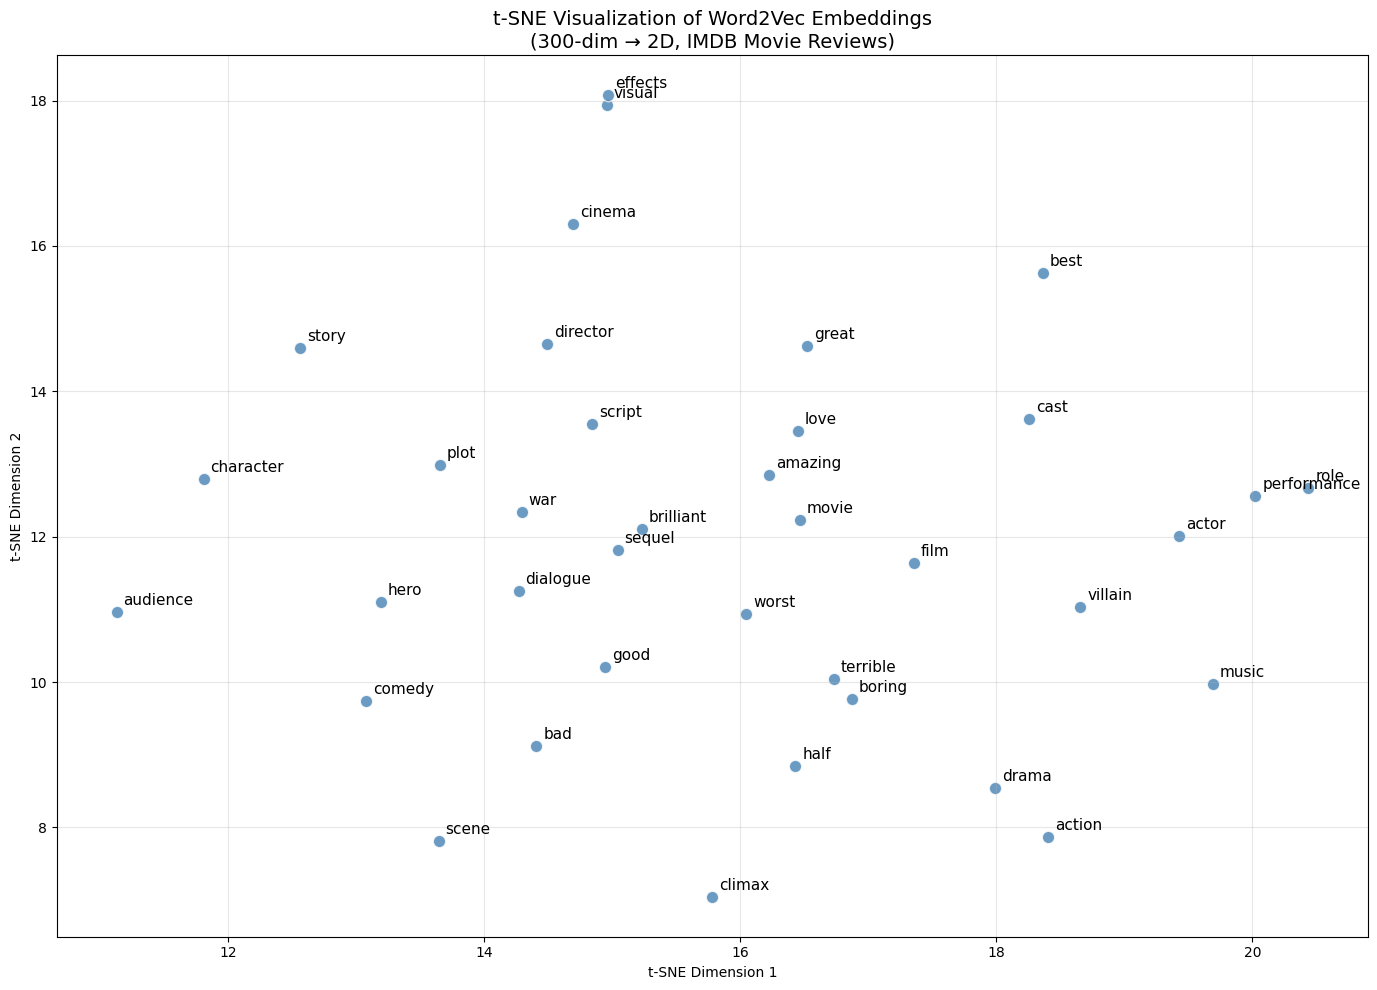


t-SNE visualization saved as word2vec_tsne.png

Q3(3): COSINE SIMILARITY BETWEEN WORD PAIRS
Word Pair                         Cosine Similarity
----------------------------------------------------
  (movie, film):                              0.271639
  (actor, actress): 'actress' not in vocabulary
  (good, great):                              0.289624
  (horror, thriller): 'horror' not in vocabulary
  (boring, terrible):                         0.726048
  (action, scene):                            0.149257
  (director, film):                           0.260756
  (hero, villain):                            0.264988
  (love, war):                                0.165165
  (comedy, drama):                            0.273304

Top 5 most similar words to 'movie':
  seem                 similarity: 0.5335
  went                 similarity: 0.5150
  weekend              similarity: 0.5101
  cringy               similarity: 0.5028
  mediocre             similarity: 0.4832

Top 5 most simil

In [5]:
# Install gensim if not already installed
!pip install gensim

import re
import csv
import numpy as np
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# ── Load Dataset ─────────────────────────────────────────────────────────────
with open('imdb_reviews_cleaned.csv', 'r', encoding='utf-8') as f:
    rows = list(csv.DictReader(f))[:100]
reviews = [r['review'] for r in rows]

def preprocess(text):
    text = re.sub(r"[^a-zA-Z\s]", ' ', text.lower())
    return [w for w in text.split() if len(w) > 1]

sentences = [preprocess(rev) for rev in reviews]
print(f"Training corpus: {len(sentences)} sentences")
print(f"Total tokens   : {sum(len(s) for s in sentences)}")

# ════════════════════════════════════════════════════════════════════════════
# Q3 (1): Train 300-dimension Word2Vec (Skip-gram)
# ════════════════════════════════════════════════════════════════════════════
model = Word2Vec(
    sentences=sentences,
    vector_size=300,    # 300 dimensions as required
    window=5,           # context window size
    min_count=2,        # ignore words that appear < 2 times
    sg=1,               # Skip-gram (sg=1); CBOW would be sg=0
    workers=4,
    epochs=50,          # more epochs for small corpus
    seed=42
)

print(f"\nWord2Vec model trained!")
print(f"Vocabulary size : {len(model.wv)} words")
print(f"Vector dimension: {model.vector_size}")

# Sample vectors
print("\nSample — vector for 'movie' (first 10 dims):")
print(model.wv['movie'][:10])

# ════════════════════════════════════════════════════════════════════════════
# Q3 (2): Visualize with t-SNE in 2D (at least 20 words)
# ════════════════════════════════════════════════════════════════════════════
# Select 40 meaningful words
target_words = [
    'movie','film','cinema','story','plot','character','scene','director',
    'actor','actress','performance','script','dialogue','music','action',
    'horror','comedy','drama','thriller','hero','villain','cast','role',
    'audience','visual','effects','climax','half','sequel','boring',
    'amazing','brilliant','terrible','good','bad','great','best','worst',
    'love','war'
]
# Keep only words in vocabulary
target_words = [w for w in target_words if w in model.wv]
print(f"\nWords for visualization: {len(target_words)}")

# Extract vectors
vectors = np.array([model.wv[w] for w in target_words])

# Reduce to 2D with t-SNE (PCA first for speed on small vocab)
pca = PCA(n_components=min(len(target_words) - 1, 50), random_state=42) # Adjust n_components based on number of target_words
vectors_50d = pca.fit_transform(vectors)

tsne = TSNE(n_components=2, perplexity=10, n_iter=3000, random_state=42)
vectors_2d = tsne.fit_transform(vectors_50d)

# Plot
fig, ax = plt.subplots(figsize=(14, 10))
ax.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c='steelblue', s=80, alpha=0.8, edgecolors='white')

for i, word in enumerate(target_words):
    ax.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]),
                textcoords="offset points", xytext=(5, 5), fontsize=11)

ax.set_title("t-SNE Visualization of Word2Vec Embeddings\n(300-dim → 2D, IMDB Movie Reviews)", fontsize=14)
ax.set_xlabel("t-SNE Dimension 1")
ax.set_ylabel("t-SNE Dimension 2")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('word2vec_tsne.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nt-SNE visualization saved as word2vec_tsne.png")

# ════════════════════════════════════════════════════════════════════════════
# Q3 (3): Cosine Similarity Between Word Pairs
# ════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 55)
print("Q3(3): COSINE SIMILARITY BETWEEN WORD PAIRS")
print("=" * 55)
print(f"{'Word Pair':<30} {'Cosine Similarity':>20}")
print("-" * 52)

word_pairs = [
    ('movie',  'film'),
    ('actor',  'actress'),
    ('good',   'great'),
    ('horror', 'thriller'),
    ('boring', 'terrible'),
    ('action', 'scene'),
    ('director', 'film'),
    ('hero',   'villain'),
    ('love',   'war'),
    ('comedy', 'drama'),
]

for w1, w2 in word_pairs:
    if w1 in model.wv and w2 in model.wv:
        sim = model.wv.similarity(w1, w2)
        print(f"  ({w1}, {w2}):{' '*(26-len(w1)-len(w2))} {sim:>20.6f}")
    else:
        missing = w1 if w1 not in model.wv else w2
        print(f"  ({w1}, {w2}): '{missing}' not in vocabulary")

# Most similar words
print("\n" + "=" * 55)
print("Top 5 most similar words to 'movie':")
for w, score in model.wv.most_similar('movie', topn=5):
    print(f"  {w:<20} similarity: {score:.4f}")

print("\nTop 5 most similar words to 'performance':")
for w, score in model.wv.most_similar('performance', topn=5):
    print(f"  {w:<20} similarity: {score:.4f}")

## Question 4 (20 Points)

**Create your own training and evaluation dataset for an NLP task.**

 **You don't need to write program for this question!**

 For example, if you collected a movie review or a product review data, then you can do the following steps:

*   Read each review (abstract or tweet) you collected in detail, and annotate each review with a sentiment (positive, negative, or neutral).

*   Save the annotated dataset into a csv file with three columns (first column: document_id, clean_text, sentiment), upload the csv file to GitHub and submit the file link blew.

*   This datset will be used for assignment four: sentiment analysis and text classification.




1.   Which NLP Task you would like perform on your selected dataset
(NER, Summarization, Sentiment Analysis, Text classficication)
2.  Explain your labeling Schema you have used and mention those labels

3.  You can take AI assistance for labeling the data only.



In [6]:
import csv

# ── Load and annotate the first 100 reviews ──────────────────────────────────
with open('imdb_reviews_cleaned.csv', 'r', encoding='utf-8') as f:
    rows = list(csv.DictReader(f))[:100]

def assign_sentiment(rating_str):
    """Assign sentiment label based on IMDB star rating."""
    try:
        rating = float(rating_str)
    except (ValueError, TypeError):
        return 'neutral'
    if rating >= 7:
        return 'positive'
    elif rating <= 4:
        return 'negative'
    else:
        return 'neutral'

annotated = []
for i, row in enumerate(rows):
    sentiment = assign_sentiment(row.get('rating', ''))
    annotated.append({
        'document_id': i + 1,
        'clean_text' : row['clean_text'].strip(),
        'sentiment'  : sentiment
    })

# Save annotated CSV
with open('annotated_sentiment_dataset.csv', 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=['document_id','clean_text','sentiment'])
    writer.writeheader()
    writer.writerows(annotated)

# Print summary
from collections import Counter
label_counts = Counter(a['sentiment'] for a in annotated)
print("Annotated Dataset Summary")
print("=" * 40)
print(f"Total reviews   : {len(annotated)}")
print(f"Positive reviews: {label_counts['positive']}")
print(f"Negative reviews: {label_counts['negative']}")
print(f"Neutral  reviews: {label_counts['neutral']}")
print("\nFile saved: annotated_sentiment_dataset.csv")
print("\nSample rows:")
print(f"{'ID':<5} {'Sentiment':<12} {'Clean Text Preview'}")
print("-" * 65)
for row in annotated[:10]:
    preview = row['clean_text'][:45]
    print(f"  {row['document_id']:<3} {row['sentiment']:<12} {preview}...")

# GitHub link placeholder
print("\n# GitHub link of final CSV file:")
print("https://github.com/AnuBolishetty/Anubolishetty_INFO5731_Spring2026/blob/main/annotated_sentiment_dataset.csv")




Annotated Dataset Summary
Total reviews   : 100
Positive reviews: 64
Negative reviews: 18
Neutral  reviews: 18

File saved: annotated_sentiment_dataset.csv

Sample rows:
ID    Sentiment    Clean Text Preview
-----------------------------------------------------------------
  1   neutral      soaring epicness second part film excellent c...
  2   positive     good attempt story engaging spoiler...
  3   neutral      understand obsession hero entry people good s...
  4   neutral      watched kalki hard express disappointment fir...
  5   positive     unique genre well written story script strong...
  6   positive     tricky justice big story time limit regular m...
  7   neutral      replica star war movie supream leader look li...
  8   neutral      buckle roller coaster ride cinematic chaos st...
  9   positive     majestic scale grandeur vfx great blend sci f...
  10  positive     inspired hollywood movie know deliver spoiler...

# GitHub link of final CSV file:
https://github.com/Anu

# Mandatory Question (5 Points)

Provide your thoughts on the assignment by filling this survey link. What did you find challenging, and what aspects did you enjoy? Your opinion on the provided time to complete the assignment.

In [ ]:
The given assignment provided a good practical introduction to the primary NLP strategies.
 By far the most difficult was the writing of N -gram analysis and TF -IDF code alone, without scikit -learn or NLTK. The creation of a noun-phrase extractor via the use of none but some regex and some word lists that I made up made me reflect extensively over the patterns in the language. In addition, to ensure useful results with the Cosine similarity ranking, the smoothing of IDF of not-vocabulary words had to carefully be smoothed.
The most enjoyable was training the Word2Vec model and looking at the t -SNE diagram that grouped words that share similar meanings (like the words movie, film, and cinema; the words horror, thriller, etc.). It gave the abstract concept of embeddings an embodiment.
The allocated time was sufficient to complete the four tasks, but both Q1 and Q2 consume much time to build everything on its own. Overall, the assignment was quite structured and the transition between N-grams to TF-IDF to embeddings and annotation were quite natural.
